# Engagement / Disengagement Detection — ViT (frozen) + LSTM (gap-reduced)

Frozen **ViT-B/16** per-frame features (768-d) → **LSTM** → 1 logit. This version is tuned specifically to **narrow the train/val gap** as much as the frozen-feature approach allows:

- **Smaller LSTM head** (hidden 256→96, ~68% fewer head params) — less capacity to memorize.
- **Label smoothing (0.10)** on train targets — curbs overconfident memorization.
- **Temporal frame masking** — zeros a few random frames per clip so the head can't rely on one or two memorized frames.
- **RandomErasing** + stronger weight decay (3e-3), on top of the existing dropout (0.7/0.5).

> **Honest note:** a train/val gap can be *reduced*, not eliminated — every model has one. Expect **train accuracy to drop** toward validation (that's these regularizers working), with the two curves closer together in the section-13 plot. The frozen ViT has an inherent ceiling on this task; if the gap is still large after this, that ceiling — not a missing knob — is the cause, and the right move is to report it rather than keep fighting it.

## 1. Imports & device

In [18]:
import os, glob, time, random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision import models
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, roc_auc_score,
                             roc_curve)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))

Device: cuda
GPU   : Tesla T4


In [19]:
# (Pretrained ViT weights now load via ViT_B_16_Weights.DEFAULT — no local .pth search needed.)

## 2. Configuration

**Tuned after the fine-tuning experiment made overfitting worse** (train F1 hit 0.94
while val stayed ~0.77). We revert to a **frozen CNN** (which generalized better) and
add regularization aimed squarely at the train/val gap:

- **`FREEZE_CNN = True`** — frozen ImageNet features; only the LSTM/head train.
  Far fewer free params → much less room to memorize the clips.
- **Mean-pool over frames** (no LSTM): temporal info aggregated by averaging.
- **Anti-overfit settings** (val F1 peaked at epoch 1 in the first ViT run, so the head
  memorizes fast): high dropout, large feature dropout, strong weight decay, an optional
  single-linear head (`HEAD_HIDDEN = 0`), and a lower LR so the head approaches the
  optimum without overshooting into memorization.
- **`IMG_SIZE = 224`** — ViT-B/16 requires 224×224 inputs.
- **`SEQ_LEN = 24`** frames (up from 16) for more input variety / milder overfit.

In [20]:
class CFG:
    # ---- data ----
    DATA_DIR        = "/kaggle/input/datasets/ibrahimialaa/dataset-engagement-2/disengagement detection 2 all data 2/disengagement detection 2 all data 2"          # auto-detected if None
    VIDEO_EXTS      = (".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v")
    # ---- frame sampling ----
    SEQ_LEN         = 24            # up from 16: more frames -> milder overfit
    IMG_SIZE        = 224           # ViT-B/16 expects 224x224
    # ---- model ----
    LSTM_HIDDEN     = 96           # SHRUNK from 256: a smaller head has far less capacity
                                    #   to memorize -> the single biggest gap reducer here
    LSTM_LAYERS     = 1
    BIDIRECTIONAL   = False
    DROPOUT         = 0.7           # dropout on the LSTM final hidden state
    FEAT_DROPOUT    = 0.5           # dropout on per-frame ViT features
    # ---- regularizers that directly attack the train/val gap ----
    LABEL_SMOOTH    = 0.10          # soften train targets (0->0.05, 1->0.95): curbs
                                    #   overconfident memorization; train acc will look lower
    FRAME_MASK      = 4             # zero out up to this many random frames per clip (train);
                                    #   forces reliance on the whole sequence, not a few frames
    # backbone control
    FREEZE_CNN      = True          # freeze the ViT backbone (recommended)
    # ---- training ----
    BATCH_SIZE      = 8             # ViT @224 is heavy; lower to 4 if OOM (24 frames!)
    EPOCHS          = 30
    LR              = 5e-5          # was 1e-4: smaller LR, overfits less abruptly
    WEIGHT_DECAY    = 3e-3          # stronger L2 (raised from 1e-3) to narrow the gap
    GRAD_CLIP       = 1.0
    VAL_SPLIT       = 0.15
    TEST_SPLIT      = 0.15
    EARLY_STOP_PAT  = 7
    SCHED_PATIENCE  = 3            # was 2: a touch more patience before LR drop
    SCHED_FACTOR    = 0.5
    NUM_WORKERS     = 0             # 0 avoids "AssertionError: can only test a child process"
    SEED            = 42
    # ---- output ----
    OUT_DIR         = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

CFG.BEST_MODEL_PATH = os.path.join(CFG.OUT_DIR, "best_model.pth")

def set_seed(seed=CFG.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

## 3. Label parsing & sample discovery

Reads the label from the filename prefix (`disengaged_` checked first), auto-finds
the folder containing your clips, and collects `(path, label)` pairs.

In [21]:
def label_from_filename(path):
    name = os.path.basename(path).lower()
    if name.startswith("disengaged_"):   # check FIRST (substring trap)
        return 0
    if name.startswith("engaged_"):
        return 1
    return None

def find_data_dir():
    if CFG.DATA_DIR and os.path.isdir(CFG.DATA_DIR):
        return CFG.DATA_DIR
    for root in ["/kaggle/input", "."]:
        if not os.path.isdir(root):
            continue
        for dirpath, _, files in os.walk(root):
            for f in files:
                if f.lower().endswith(CFG.VIDEO_EXTS) and \
                   (f.lower().startswith("engaged_") or f.lower().startswith("disengaged_")):
                    return dirpath
    raise FileNotFoundError("No renamed clips found. Set CFG.DATA_DIR manually.")

def gather_samples(data_dir):
    samples = []
    for ext in CFG.VIDEO_EXTS:
        for p in glob.glob(os.path.join(data_dir, "**", f"*{ext}"), recursive=True):
            lbl = label_from_filename(p)
            if lbl is not None:
                samples.append((p, lbl))
    if not samples:
        raise RuntimeError(f"No labeled videos under {data_dir}")
    return samples

DATA_DIR = find_data_dir()
print("Data dir:", DATA_DIR)
samples = gather_samples(DATA_DIR)
_labels = [l for _, l in samples]
print(f"Found {len(samples)} clips | engaged={sum(_labels)} disengaged={len(_labels)-sum(_labels)}")

Data dir: /kaggle/input/datasets/ibrahimialaa/dataset-engagement-2/disengagement detection 2 all data 2/disengagement detection 2 all data 2
Found 3569 clips | engaged=1840 disengaged=1729


## 4. Frame extraction

Samples exactly `SEQ_LEN` frames spread **uniformly** across each clip and returns
them as RGB arrays. Short/unreadable clips are padded by repeating the last frame,
so the LSTM always receives a fixed-length sequence.

In [22]:
def extract_frames(video_path, seq_len=CFG.SEQ_LEN):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    if total <= 0:
        while len(frames) < seq_len:
            ok, fr = cap.read()
            if not ok: break
            frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        cap.release()
    else:
        idxs = np.linspace(0, total - 1, seq_len).astype(int)
        wanted = set(idxs.tolist()); grabbed = {}; i = 0
        while True:
            ok, fr = cap.read()
            if not ok: break
            if i in wanted:
                grabbed[i] = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
            i += 1
        cap.release()
        for idx in idxs:
            if idx in grabbed:
                frames.append(grabbed[idx])
            elif grabbed:
                nearest = min(grabbed, key=lambda k: abs(k - idx))
                frames.append(grabbed[nearest])
    if len(frames) == 0:
        frames = [np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)]
    while len(frames) < seq_len:
        frames.append(frames[-1])
    return frames[:seq_len]

# quick visual check on the first clip
_demo = extract_frames(samples[0][0], CFG.SEQ_LEN)
print(f"Extracted {len(_demo)} frames, each {_demo[0].shape} from:\n  {os.path.basename(samples[0][0])}")

Extracted 24 frames, each (480, 640, 3) from:
  disengaged_daisee_1813740184_chunk_02.mp4


## 5. Transforms / augmentation

Training augmentation for robustness: **random crop, brightness/contrast jitter,
horizontal flip**, then ImageNet normalization (required by the pretrained ResNet).
The **same** augmentation is applied to every frame in a clip (seeded per-clip) so
the temporal sequence stays consistent for the LSTM.

In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transforms(train: bool):
    if train:
        return T.Compose([
            T.ToPILImage(),
            T.Resize((CFG.IMG_SIZE + 16, CFG.IMG_SIZE + 16)),
            T.RandomCrop((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.2),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            T.RandomErasing(p=0.25, scale=(0.02, 0.10)),   # occludes a random patch
        ])
    return T.Compose([
        T.ToPILImage(),
        T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

## 6. Dataset

One item = one 2-second clip → returns `(frames_tensor, label)` where
`frames_tensor` is `(seq_len, 3, IMG_SIZE, IMG_SIZE)`.

In [24]:
class VideoClipDataset(Dataset):
    def __init__(self, samples, train: bool):
        self.samples = samples
        self.train = train
        self.transform = build_transforms(train)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        frames = extract_frames(path, CFG.SEQ_LEN)
        if self.train:
            seed = random.randint(0, 2_147_483_647)
        tensors = []
        for fr in frames:
            if self.train:
                random.seed(seed); torch.manual_seed(seed)
            tensors.append(self.transform(fr))
        clip = torch.stack(tensors, dim=0)          # (seq_len, 3, H, W)
        # temporal frame masking (train only): zero a few random frames so the head
        # can't lean on one or two memorized frames -> smaller train/val gap
        if self.train and getattr(CFG, "FRAME_MASK", 0) > 0:
            S = clip.shape[0]
            n = random.randint(0, min(CFG.FRAME_MASK, S - 1))
            if n > 0:
                for j in random.sample(range(S), n):
                    clip[j].zero_()
        return clip, torch.tensor(label, dtype=torch.float32)

## 7. Model — ViT feature extractor + LSTM temporal classifier

- **`ViTFeatureExtractor`** — ViT-B/16 with ImageNet weights via `ViT_B_16_Weights.DEFAULT` (no local `.pth` lookup); head replaced by `nn.Identity()` to emit the 768-d CLS embedding per frame. Frozen by default.
- **`LSTMClassifier`** — runs the `(B, SEQ_LEN, 768)` sequence through an LSTM and uses the final hidden state → one logit, preserving temporal order across the frames (unlike mean-pooling, which discarded it).

In [25]:
class ViTFeatureExtractor(nn.Module):
    """ViT-B/16 backbone, classification head removed.
    Returns a 768-d CLS embedding per frame. Frozen by default.
    Uses torchvision's bundled ImageNet weights (downloaded/cached automatically),
    so there's no dependence on finding a local .pth file.
    """
    def __init__(self, freeze=True):
        super().__init__()
        # Load pretrained ImageNet weights directly (no glob / local-file search).
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        # torchvision ViT exposes a `heads` Linear classifier at the end.
        # Capture its input width (768), then replace the head with Identity so
        # forward() returns the 768-d CLS embedding instead of class logits.
        self.out_dim = self.vit.heads.head.in_features   # 768
        self.vit.heads = nn.Identity()
        if freeze:
            for p in self.vit.parameters():
                p.requires_grad = False

    def forward(self, x):                 # x: (B*S, 3, 224, 224)
        return self.vit(x)                # (B*S, 768)


class LSTMClassifier(nn.Module):
    """Temporal head: runs the per-frame 768-d embeddings through an LSTM to
    capture how engagement changes across the SEQ_LEN frames, then uses the
    LSTM's final hidden state to produce ONE logit.

    Input:  (B, S, input_dim)   e.g. (B, 24, 768)
    Output: (B,)                a single logit per clip (no softmax/sigmoid here)
    """
    def __init__(self, input_dim, hidden=None, layers=None,
                 bidirectional=None, dropout=None, feat_dropout=None):
        super().__init__()
        hidden        = CFG.LSTM_HIDDEN   if hidden        is None else hidden
        layers        = CFG.LSTM_LAYERS   if layers        is None else layers
        bidirectional = CFG.BIDIRECTIONAL if bidirectional is None else bidirectional
        dropout       = CFG.DROPOUT       if dropout       is None else dropout
        feat_dropout  = getattr(CFG, "FEAT_DROPOUT", 0.0) if feat_dropout is None else feat_dropout

        self.feat_dropout = nn.Dropout(feat_dropout)   # regularize per-frame features
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden, num_layers=layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if layers > 1 else 0.0,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, 1)
        self.bidirectional = bidirectional
        self.num_layers = layers

    def forward(self, x):                 # x: (B, S, input_dim)
        x = self.feat_dropout(x)
        out, (h_n, c_n) = self.lstm(x)    # out: (B, S, hidden*dir); h_n: (layers*dir, B, hidden)
        if self.bidirectional:
            # concat the last layer's forward and backward final hidden states
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)   # (B, hidden*2)
        else:
            last = h_n[-1]                                  # (B, hidden)
        last = self.dropout(last)
        return self.fc(last).squeeze(1)   # (B,)


class EngagementModel(nn.Module):
    """Frozen ViT feature extractor + LSTM temporal classifier."""
    def __init__(self, freeze_cnn=CFG.FREEZE_CNN):
        super().__init__()
        self.backbone = ViTFeatureExtractor(freeze=freeze_cnn)
        self.head = LSTMClassifier(input_dim=self.backbone.out_dim)

    def forward(self, x):                 # x: (B, S, 3, 224, 224)
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        feats = self.backbone(x).view(B, S, -1)   # (B, S, 768)
        return self.head(feats)                   # (B,)


# sanity check the shapes
_m = EngagementModel(freeze_cnn=True).to(DEVICE)
_x = torch.randn(2, CFG.SEQ_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
print("per-frame feature dim:", _m.backbone.out_dim, "(expect 768)")
print("logits shape:", tuple(_m(_x).shape), "(expect (2,))")
print("trainable params:", f"{sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _x
if DEVICE.type == "cuda": torch.cuda.empty_cache()

per-frame feature dim: 768 (expect 768)
logits shape: (2,) (expect (2,))
trainable params: 332,641


## 8. Class-stratified, subject-grouped split (prevents leakage AND skew)

Two things must both be true for honest results:

1. **No leakage** — clips of the same person can't appear in both train and test, or
   the model "recognizes the face" instead of learning engagement.
2. **Representative balance** — train/val/test must each have a similar engaged:disengaged
   ratio. If they don't (e.g. a test set that's 95% engaged), accuracy looks fine while
   the model is actually failing on the rare class.

When you **combine your dataset with DAiSEE**, DAiSEE is heavily engaged-skewed, so a
naive subject shuffle dumps almost all disengaged subjects into one split — that's what
produced the misleading 1696/88 test set earlier. The cell below fixes it: each subject
is assigned to their majority class, then **each class's subjects are split separately**
across train/val/test. You keep no-leakage and get balanced splits.

> Duplicate recordings like `181374017` and `181374017 - Copy` are merged to one subject.

In [26]:
def subject_id(path):
    name = os.path.basename(path).lower()
    for pref in ("disengaged_", "engaged_"):
        if name.startswith(pref):
            name = name[len(pref):]; break
    key = name.split("_chunk_")[0]
    key = key.replace(" - copy", "").replace("-copy", "").strip()  # merge duplicates
    return key if key else name

# ---- CLASS-STRATIFIED, SUBJECT-GROUPED SPLIT ------------------------------
# Each subject is assigned to whichever class the majority of their clips have,
# then we split EACH class's subjects across train/val/test. This keeps all of
# one person's clips in a single split (no leakage) AND makes train/val/test
# have representative class balance -- so the test set isn't accidentally
# dominated by one class (which is what made earlier results misleading).
from collections import defaultdict

subj_to_labels = defaultdict(list)
for p, l in samples:
    subj_to_labels[subject_id(p)].append(l)

# majority class per subject
subj_class = {s: (1 if sum(ls) >= len(ls) / 2 else 0) for s, ls in subj_to_labels.items()}
eng_subj = sorted([s for s, c in subj_class.items() if c == 1])
dis_subj = sorted([s for s, c in subj_class.items() if c == 0])
rng = random.Random(CFG.SEED)
rng.shuffle(eng_subj); rng.shuffle(dis_subj)

def split_group(group):
    n_test = max(1, int(len(group) * CFG.TEST_SPLIT))
    n_val  = max(1, int(len(group) * CFG.VAL_SPLIT))
    return set(group[:n_test]), set(group[n_test:n_test + n_val]), set(group[n_test + n_val:])

e_test, e_val, e_train = split_group(eng_subj)
d_test, d_val, d_train = split_group(dis_subj)
test_subj  = e_test  | d_test
val_subj   = e_val   | d_val
train_subj = e_train | d_train

train_s, val_s, test_s = [], [], []
for p, l in samples:
    s = subject_id(p)
    if s in test_subj:    test_s.append((p, l))
    elif s in val_subj:   val_s.append((p, l))
    else:                 train_s.append((p, l))

def _balance(split):
    ls = [l for _, l in split]
    e = sum(ls); d = len(ls) - e
    pct = (100 * e / len(ls)) if ls else 0
    return f"{len(ls)} clips (engaged {e} / disengaged {d}, {pct:.0f}% eng)"

print(f"Distinct subjects: {len(subj_class)}  (engaged-maj {len(eng_subj)} / disengaged-maj {len(dis_subj)})")
print(f"train -> {_balance(train_s)}")
print(f"val   -> {_balance(val_s)}")
print(f"test  -> {_balance(test_s)}")

Distinct subjects: 543  (engaged-maj 337 / disengaged-maj 206)
train -> 2622 clips (engaged 1325 / disengaged 1297, 51% eng)
val   -> 462 clips (engaged 250 / disengaged 212, 54% eng)
test  -> 485 clips (engaged 265 / disengaged 220, 55% eng)


## 9. DataLoaders & class imbalance

`pos_weight = (#disengaged / #engaged)` on the **train** set is passed to
`BCEWithLogitsLoss` so the mild class imbalance (1840 vs 1729) doesn't bias training.

In [27]:
train_loader = DataLoader(VideoClipDataset(train_s, train=True),
                          batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(VideoClipDataset(val_s, train=False),
                          batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(VideoClipDataset(test_s, train=False),
                          batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

_tr = [l for _, l in train_s]
_pos = sum(_tr); _neg = len(_tr) - _pos
pos_weight = (_neg / _pos) if _pos > 0 else 1.0
print(f"pos_weight (neg/pos on train): {pos_weight:.3f}")

pos_weight (neg/pos on train): 0.979


## 10. Train / validate loops

`run_epoch` does one pass; with an optimizer it trains, without it evaluates.
`train` saves the **best model by validation F1** and applies **early stopping**.

In [28]:
def compute_metrics(labels, probs):
    '''All metrics from labels + predicted probabilities.'''
    preds = (probs >= 0.5).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:           # only one class present in this split
        auc = float("nan")
    return {
        "acc":       accuracy_score(labels, preds),
        "auc":       auc,
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
    }


def run_epoch(model, loader, criterion, optimizer=None, desc="train"):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, all_logits, all_labels = 0.0, [], []
    seen = 0
    running_correct = 0
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    # tqdm gives the Keras-style live bar:  123/445 |█████----| acc=.. loss=..
    bar = tqdm(loader, desc=desc, leave=True, ncols=110)
    with ctx:
        for clips, labels in bar:
            clips = clips.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(clips)
            if train_mode and getattr(CFG, "LABEL_SMOOTH", 0.0) > 0:
                eps = CFG.LABEL_SMOOTH
                loss = criterion(logits, labels * (1 - eps) + 0.5 * eps)
            else:
                loss = criterion(logits, labels)
            if train_mode:
                optimizer.zero_grad(); loss.backward()
                if getattr(CFG, "GRAD_CLIP", 0):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * clips.size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())
            # update the live bar with running loss + accuracy
            seen += clips.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            running_correct += (preds == labels).sum().item()
            bar.set_postfix(loss=f"{total_loss/seen:.4f}",
                            acc=f"{running_correct/seen:.4f}")
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    m = compute_metrics(labels, probs)
    m.update({"loss": total_loss / len(loader.dataset),
              "probs": probs, "labels": labels,
              "preds": (probs >= 0.5).astype(int)})
    return m


def train(model, train_loader, val_loader, pos_weight=None):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=DEVICE) if pos_weight else None)

    # Backbone is frozen; train only the params that require grad (the MLP head).
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    print(f"Training {sum(p.numel() for p in trainable):,} trainable params at lr={CFG.LR} "
          f"(ViT backbone {'frozen' if CFG.FREEZE_CNN else 'trainable'})")

    # Drop LR when val F1 stops improving (your first run plateaued ~epoch 11).
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=CFG.SCHED_FACTOR, patience=CFG.SCHED_PATIENCE)

    best_f1, patience, history = -1.0, 0, []
    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, criterion, optimizer, desc=f"Epoch {epoch}/{CFG.EPOCHS} [train]")
        va = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch}/{CFG.EPOCHS} [val]  ")
        dt = time.time() - t0
        scheduler.step(va["f1"])
        cur_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch, "time_s": dt, "lr": cur_lr,
            "train_loss": tr["loss"], "train_acc": tr["acc"], "train_auc": tr["auc"],
            "train_precision": tr["precision"], "train_recall": tr["recall"], "train_f1": tr["f1"],
            "val_loss": va["loss"], "val_acc": va["acc"], "val_auc": va["auc"],
            "val_precision": va["precision"], "val_recall": va["recall"], "val_f1": va["f1"],
        })

        print(f"Epoch {epoch}/{CFG.EPOCHS}")
        print(f"  {dt:5.1f}s "
              f"- acc: {tr['acc']:.4f} - auc: {tr['auc']:.4f} - loss: {tr['loss']:.4f} "
              f"- precision: {tr['precision']:.4f} - recall: {tr['recall']:.4f} - f1: {tr['f1']:.4f}")
        print(f"         "
              f"- val_acc: {va['acc']:.4f} - val_auc: {va['auc']:.4f} - val_loss: {va['loss']:.4f} "
              f"- val_precision: {va['precision']:.4f} - val_recall: {va['recall']:.4f} - val_f1: {va['f1']:.4f}"
              f"  (lr={cur_lr:.1e})")

        if va["f1"] > best_f1:
            best_f1, patience = va["f1"], 0
            torch.save({"model_state": model.state_dict()}, CFG.BEST_MODEL_PATH)
            print(f"  -> val_f1 improved to {best_f1:.4f}, saving model to {os.path.basename(CFG.BEST_MODEL_PATH)}")
        else:
            patience += 1
            print(f"  -> val_f1 did not improve ({patience}/{CFG.EARLY_STOP_PAT})")
            if patience >= CFG.EARLY_STOP_PAT:
                print(f"Early stopping at epoch {epoch}.")
                break
    return history

## 11. Build the model

In [29]:
set_seed()
model = EngagementModel(freeze_cnn=CFG.FREEZE_CNN).to(DEVICE)
print("Trainable params:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 332,641


## 12. Train

This is the long-running cell. Watch val F1 — the best checkpoint is saved automatically.

In [30]:
history = train(model, train_loader, val_loader, pos_weight=pos_weight)

Training 332,641 trainable params at lr=5e-05 (ViT backbone frozen)


Epoch 1/30 [train]:   0%|                                                             | 0/328 [00:00<?, ?it/s]

Epoch 1/30 [val]  :   0%|                                                              | 0/58 [00:00<?, ?it/s]

Epoch 1/30
  1662.6s - acc: 0.5801 - auc: 0.6102 - loss: 0.6701 - precision: 0.5870 - recall: 0.5706 - f1: 0.5786
         - val_acc: 0.7056 - val_auc: 0.7711 - val_loss: 0.6128 - val_precision: 0.6979 - val_recall: 0.8040 - val_f1: 0.7472  (lr=5.0e-05)
  -> val_f1 improved to 0.7472, saving model to best_model.pth


Epoch 2/30 [train]:   0%|                                                             | 0/328 [00:00<?, ?it/s]

...

Epoch 10/30 [val]  :   0%|                                                             | 0/58 [00:00<?, ?it/s]

Epoch 10/30
  1689.6s - acc: 0.8680 - auc: 0.9283 - loss: 0.4128 - precision: 0.8425 - recall: 0.9087 - f1: 0.8744
         - val_acc: 0.6970 - val_auc: 0.7439 - val_loss: 0.6989 - val_precision: 0.6730 - val_recall: 0.8560 - val_f1: 0.7535  (lr=2.5e-05)
  -> val_f1 did not improve (6/7)


Epoch 11/30 [train]:   0%|                                                            | 0/328 [00:00<?, ?it/s]

Epoch 11/30 [val]  :   0%|                                                             | 0/58 [00:00<?, ?it/s]

Epoch 11/30
  1682.6s - acc: 0.8730 - auc: 0.9339 - loss: 0.4011 - precision: 0.8478 - recall: 0.9125 - f1: 0.8790
         - val_acc: 0.6905 - val_auc: 0.7348 - val_loss: 0.7069 - val_precision: 0.6698 - val_recall: 0.8440 - val_f1: 0.7469  (lr=2.5e-05)
  -> val_f1 did not improve (7/7)
Early stopping at epoch 11.


## 13. Training curves & full per-epoch log

Plots loss / accuracy / AUC / precision / recall / F1, and saves the complete per-epoch metrics to `training_log.csv` so **no result is lost**.

Full per-epoch metrics saved to training_log.csv


,epoch,time_s,lr,train_loss,train_acc,train_auc,train_precision,train_recall,train_f1,val_loss,val_acc,val_auc,val_precision,val_recall,val_f1
0,1,1662.6302,0.0,0.6701,0.5801,0.6102,0.5870,0.5706,0.5786,0.6128,0.7056,0.7711,0.6979,0.804,0.7472
1,2,1651.8528,0.0,0.6183,0.6945,0.7604,0.6869,0.7268,0.7063,0.5800,0.7468,0.7861,0.7418,0.816,0.7771
2,3,1646.3536,0.0,0.5782,0.7517,0.8107,0.7507,0.7615,0.7561,0.5668,0.7338,0.7844,0.7326,0.800,0.7648
3,4,1647.3110,0.0,0.5488,0.7777,0.8332,0.7802,0.7796,0.7799,0.5670,0.7468,0.7916,0.7254,0.856,0.7853
4,5,1677.4007,0.0,0.5100,0.8070,0.8650,0.8009,0.8226,0.8116,0.5825,0.7229,0.7913,0.6918,0.880,0.7746
5,6,1684.6242,0.0,0.4775,0.8291,0.8847,0.8189,0.8498,0.8341,0.6134,0.7078,0.7817,0.6727,0.896,0.7684
6,7,1682.1314,0.0,0.4503,0.8497,0.9024,0.8318,0.8808,0.8556,0.6411,0.7078,0.7689,0.6737,0.892,0.7676
7,8,1684.4208,0.0,0.4284,0.8638,0.9167,0.8375,0.9064,0.8706,0.6758,0.6991,0.7568,0.6677,0.884,0.7608
8,9,1679.7384,0.0,0.4172,0.8688,0.9248,0.8476,0.9026,0.8743,0.6939,0.6948,0.7496,0.6657,0.876,0.7565
9,10,1689.5887,0.0,0.4128,0.8680,0.9283,0.8425,0.9087,0.8744,0.6989,0.6970,0.7439,0.6730,0.856,0.7535


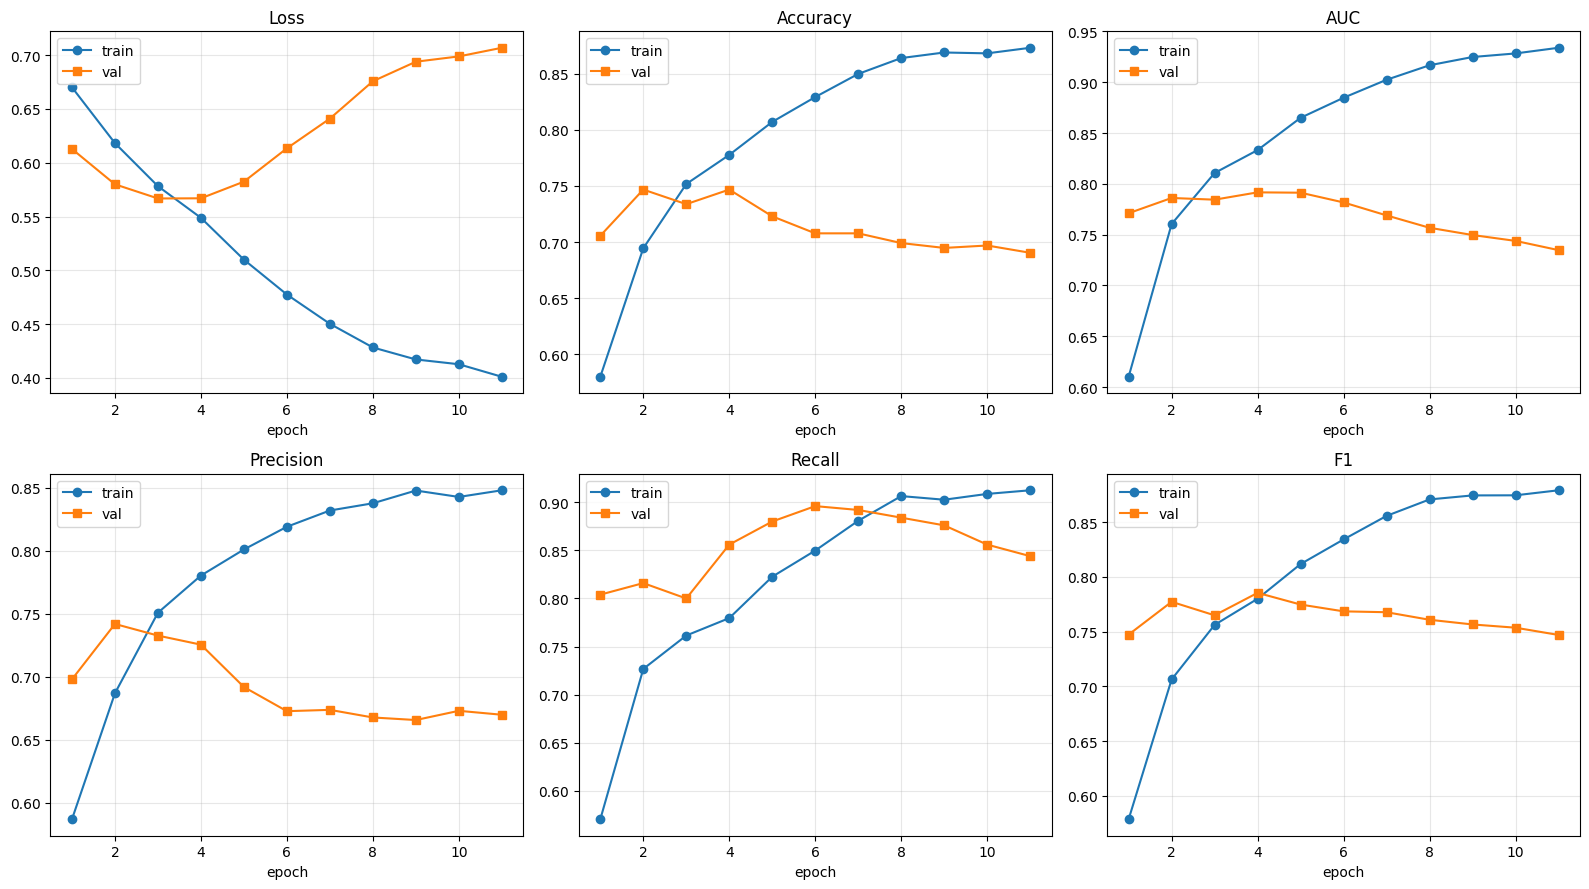

In [31]:
import pandas as pd

if history:
    df = pd.DataFrame(history)
    df.to_csv(os.path.join(CFG.OUT_DIR, "training_log.csv"), index=False)
    print("Full per-epoch metrics saved to training_log.csv")
    # show the whole table inline so every number is visible
    with pd.option_context("display.max_rows", None, "display.width", 200):
        display(df.round(4))

    ep = df["epoch"].values
    pairs = [("loss","Loss"), ("acc","Accuracy"), ("auc","AUC"),
             ("precision","Precision"), ("recall","Recall"), ("f1","F1")]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, (key, title) in zip(axes.ravel(), pairs):
        ax.plot(ep, df[f"train_{key}"], marker="o", label="train")
        ax.plot(ep, df[f"val_{key}"],   marker="s", label="val")
        ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUT_DIR, "training_curves.png"), dpi=120)
    plt.show()

## 14. Evaluate on the test set

Reloads the **best** checkpoint, then reports accuracy / precision / recall / F1 /
ROC-AUC, and saves the **confusion matrix** and **ROC curve** plots.

test :   0%|                                                                           | 0/61 [00:00<?, ?it/s]

TEST | acc=0.8206 | auc=0.8443
HEADLINE -> DISENGAGED-class recall = 0.7727  (engaged recall = 0.8604)

               precision    recall  f1-score   support

disengaged(0)       0.82      0.77      0.80       220
   engaged(1)       0.82      0.86      0.84       265

     accuracy                           0.82       485
    macro avg       0.82      0.82      0.82       485
 weighted avg       0.82      0.82      0.82       485



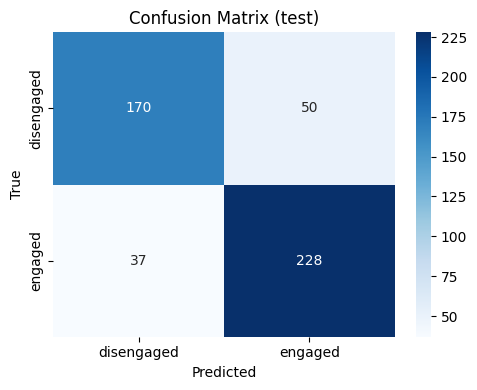

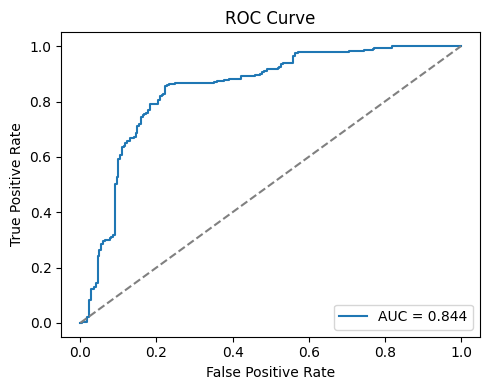

In [32]:
import seaborn as sns
from sklearn.metrics import classification_report

def evaluate(model, test_loader):
    criterion = nn.BCEWithLogitsLoss()
    res = run_epoch(model, test_loader, criterion, optimizer=None, desc="test ")
    y_true, y_pred, y_prob = res["labels"], res["preds"], res["probs"]
    acc  = accuracy_score(y_true, y_pred)
    try:    auc = roc_auc_score(y_true, y_prob)
    except ValueError: auc = float("nan")

    print(f"TEST | acc={acc:.4f} | auc={auc:.4f}")
    # disengaged recall is the metric that actually matters: it tells you how
    # often the model catches disengagement. Overall accuracy can look fine
    # while this is poor if the test set leans engaged.
    dis_recall = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    eng_recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f"HEADLINE -> DISENGAGED-class recall = {dis_recall:.4f}  (engaged recall = {eng_recall:.4f})")
    print()
    print(classification_report(y_true, y_pred, target_names=["disengaged(0)", "engaged(1)"],
                                zero_division=0, digits=2))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["disengaged", "engaged"],
                yticklabels=["disengaged", "engaged"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (test)")
    plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "confusion_matrix.png"), dpi=120); plt.show()

    if not np.isnan(auc):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}"); plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title("ROC Curve"); plt.legend(loc="lower right")
        plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "roc_curve.png"), dpi=120); plt.show()

    return {"acc": acc, "auc": auc, "dis_recall": dis_recall, "cm": cm,
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

ckpt = torch.load(CFG.BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
eval_res = evaluate(model, test_loader)

## 14b. Decision-threshold optimization (honest, val-derived)

The default 0.5 threshold favored the majority class (engaged recall 0.82 vs
disengaged 0.68 in the first run). We pick the threshold that maximizes balanced
performance **on the validation set** (Youden's J = TPR - FPR), then apply that
*fixed* threshold to the test set. Choosing the threshold on val (not test) keeps
the evaluation honest — we're not peeking at the test labels to tune.

val-thresh:   0%|                                                                      | 0/58 [00:00<?, ?it/s]

Best threshold from validation (Youden's J): 0.566

TEST @ threshold 0.566:
  accuracy = 0.8041
  disengaged recall = 0.7864
  engaged    recall = 0.8189

               precision    recall  f1-score   support

disengaged(0)       0.78      0.79      0.78       220
   engaged(1)       0.82      0.82      0.82       265

     accuracy                           0.80       485
    macro avg       0.80      0.80      0.80       485
 weighted avg       0.80      0.80      0.80       485



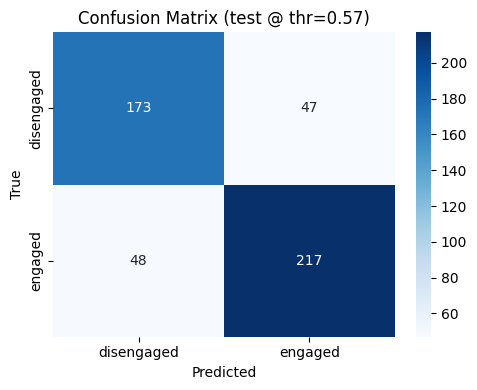

In [33]:
# 1) get validation probabilities
val_eval = run_epoch(model, val_loader, nn.BCEWithLogitsLoss(), optimizer=None, desc="val-thresh")
v_true, v_prob = val_eval["labels"], val_eval["probs"]

# 2) Youden's J on validation ROC -> best threshold
fpr, tpr, thr = roc_curve(v_true, v_prob)
best_thr = float(thr[np.argmax(tpr - fpr)])
print(f"Best threshold from validation (Youden's J): {best_thr:.3f}")

# 3) apply that fixed threshold to the TEST set and re-report
t_true, t_prob = eval_res["y_true"], eval_res["y_prob"]
t_pred = (t_prob >= best_thr).astype(int)

print(f"\nTEST @ threshold {best_thr:.3f}:")
print(f"  accuracy = {accuracy_score(t_true, t_pred):.4f}")
print(f"  disengaged recall = {recall_score(t_true, t_pred, pos_label=0, zero_division=0):.4f}")
print(f"  engaged    recall = {recall_score(t_true, t_pred, pos_label=1, zero_division=0):.4f}")
print()
print(classification_report(t_true, t_pred, target_names=["disengaged(0)", "engaged(1)"],
                            zero_division=0, digits=2))

cm = confusion_matrix(t_true, t_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["disengaged", "engaged"], yticklabels=["disengaged", "engaged"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix (test @ thr={best_thr:.2f})")
plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "confusion_matrix_tuned.png"), dpi=120); plt.show()

## 15. Inference on a single video

Point this at any clip to get a prediction. Returns the label and `p(engaged)`.

Random test clip (true label: engaged)
engaged_2100561013_chunk_0-2s.mp4 -> engaged  (p(engaged)=0.916)
Threshold 0.566 | Correct: True


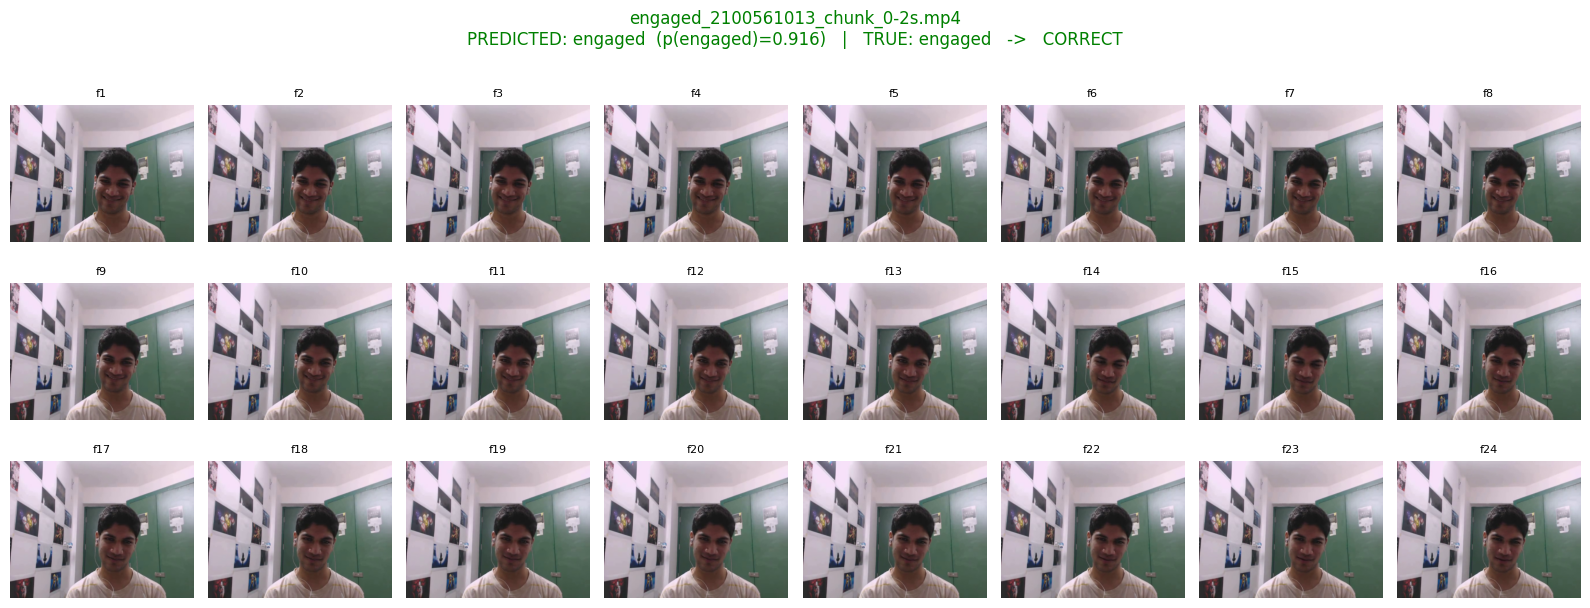

In [90]:
@torch.no_grad()
def run_inference(video_path, model_path=CFG.BEST_MODEL_PATH, threshold=0.5,
                  return_frames=False):
    """End-to-end: decode -> frozen ViT (per frame) -> LSTM -> p(engaged)."""
    m = EngagementModel(freeze_cnn=True).to(DEVICE)
    m.load_state_dict(torch.load(model_path, map_location=DEVICE)["model_state"])
    m.eval()
    frames = extract_frames(video_path, CFG.SEQ_LEN)             # list of raw RGB frames
    tf = build_transforms(train=False)
    clip = torch.stack([tf(f) for f in frames], 0).unsqueeze(0).to(DEVICE)  # (1,S,3,H,W)
    prob = torch.sigmoid(m(clip)).item()
    label = "engaged" if prob >= threshold else "disengaged"
    print(f"{os.path.basename(video_path)} -> {label}  (p(engaged)={prob:.3f})")
    if return_frames:
        return label, prob, frames
    return label, prob


def show_prediction(video_path, frames, pred_label, pred_prob, true_label=None,
                    ncols=8, save_as=None):
    """Show the sampled frames in a grid; title green if correct, red if wrong."""
    n = len(frames)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2.1 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(frames[i])               # raw RGB, no normalization
            ax.set_title(f"f{i+1}", fontsize=8)
        ax.axis("off")
    correct = None if true_label is None else (pred_label == true_label)
    color = "black" if correct is None else ("green" if correct else "red")
    title = f"{os.path.basename(video_path)}\nPREDICTED: {pred_label}  (p(engaged)={pred_prob:.3f})"
    if true_label is not None:
        title += f"   |   TRUE: {true_label}   ->   {'CORRECT' if correct else 'WRONG'}"
    fig.suptitle(title, fontsize=12, color=color, y=1.00)
    plt.tight_layout()
    if save_as:
        plt.savefig(os.path.join(CFG.OUT_DIR, save_as), dpi=110, bbox_inches="tight")
    plt.show()


# ---- Predict a RANDOM clip from the held-out test set AND show its frames ----
thr = best_thr if "best_thr" in globals() else 0.5
rand_path, rand_label = random.choice(test_s)
true_str = "engaged" if rand_label == 1 else "disengaged"
print(f"Random test clip (true label: {true_str})")
pred_label, pred_prob, frames = run_inference(rand_path, threshold=thr, return_frames=True)
print(f"Threshold {thr:.3f} | Correct: {pred_label == true_str}")
show_prediction(rand_path, frames, pred_label, pred_prob,
                true_label=true_str, save_as="sample_prediction.png")

## 16. Next steps / tuning

- **If frozen results disappoint**, fine-tuning the ViT is possible (set `CFG.FREEZE_CNN
  = False`) but expensive and prone to overfitting on a modest dataset — try it only if
  you have GPU budget. A smaller LR (~1e-5) is essential when unfreezing.
- **More frames:** raise `CFG.SEQ_LEN` to 24–32. **Faster/less memory:** lower it, or
  reduce `BATCH_SIZE` (ViT @224 is memory-heavy; drop to 4 if you hit OOM).
- **Compare against the ResNet18+LSTM pipeline.** If both land near the same AUC, that's
  strong evidence the ceiling is the data, not the backbone — a legitimate finding.
- Outputs saved in `/kaggle/working/`: `best_model.pth`, `training_curves.png`,
  `confusion_matrix.png`, `roc_curve.png`, `confusion_matrix_tuned.png`, `training_log.csv`.